# Walk-Forward Specification Selection and Out-of-Sample Validation

The earlier notebooks fixed the model specification (a GJR-GARCH(1,1) with
Student-t innovations) and the estimation window by hand. This notebook removes
that hand-fixing and asks whether those choices were fitting the *process* or
just the *sample* — the principled guard against overfitting the specification
that was flagged as the next step in notebook 01.

The procedure, for each asset independently:

- a **sliding** 1260-day (about five-year) training window, re-selected each
  calendar year;
- in every fold, the specification is chosen on the **training window only** by
  BIC, from a small grid — innovation distribution {t, skew-t} crossed with ARCH
  order p {1, 2}, holding the leverage and GARCH orders at o=1, q=1;
- the chosen spec's parameters refit every five days, with the conditional
  variance rolling daily between refits;
- one-step-ahead forecasts are pooled across all out-of-sample years and
  backtested per asset.

Three runs are compared on identical out-of-sample days: a **baseline**
(the original symmetric-t spec, forced everywhere), a **frozen** spec (selected
once on the first window and held), and a **reselected** spec (re-chosen each
year). The baseline-versus-frozen contrast isolates what the distribution choice
buys; the frozen-versus-reselected contrast measures whether adaptivity earns
its keep.

**Conventions used throughout:** volatility is annualised with 252 trading days;
VaR/ES are left-tail returns (negative); breach rates are reported, not raw
counts, because per-fold counts at the 99% level are too thin to test on their
own.

> The walk-forward re-estimates GARCH across the full history many times over;
> on ten years of three assets it runs in minutes, not seconds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from garch_risk.data import load_returns
from garch_risk.walkforward import run_walkforward, summarise
from garch_risk import plots

WINDOW, REFIT = 1260, 5

## 1. Run the walk-forward

The data layer downloads, calendar-aligns, and log-returns the three assets; the
walk-forward then runs end to end for each. Everything below reads off the
returned result objects.

In [2]:
rets = load_returns(lookback_years=10, strip_weekends=True)
print(f"{rets.shape[0]} days, {rets.index.min().date()} to {rets.index.max().date()}")

results = run_walkforward(rets, window=WINDOW, refit_every=REFIT)

2511 days, 2016-06-30 to 2026-06-26


In [3]:
for asset, res in results.items():
    print(summarise(res))
    print()

=== Walk-forward: S&P500 ===
Frozen spec (first-window, causal): skewt(1,1,1)  |  baseline (forced): t(1,1,1)

Per-fold selection (training window -> OOS year):
  year  n_oos        BIC pick        AIC pick
  2021    127    skewt(1,1,1)    skewt(2,1,1)
  2022    251    skewt(1,1,1)    skewt(1,1,1)
  2023    250    skewt(1,1,1)    skewt(2,1,1)
  2024    252    skewt(1,1,1)    skewt(1,1,1)
  2025    250    skewt(1,1,1)    skewt(1,1,1)
  2026    121    skewt(1,1,1)    skewt(1,1,1)

Pooled OOS backtest @ alpha=0.01 (expected breach rate 1.00%):
         run  breaches     rate   Kupiec p   Indep p    CC p
    baseline        17    1.36%      0.226     0.226   0.231
      frozen        12    0.96%      0.884     0.630   0.881
  reselected        12    0.96%      0.884     0.630   0.881

Pooled OOS backtest @ alpha=0.05 (expected breach rate 5.00%):
         run  breaches     rate   Kupiec p   Indep p    CC p
    baseline        76    6.08%      0.091     0.148   0.084
      frozen        53 

## 2. Which specification does the data choose, and is the choice stable?

Specification selection happens on training data only, once per fold. The grid
is small by design: every extra candidate is another chance for a spec to win a
fold by luck, so the menu is two clean axes — a tail/skew axis and a single
extra-ARCH-lag axis whose marginal value BIC is expected to penalise.

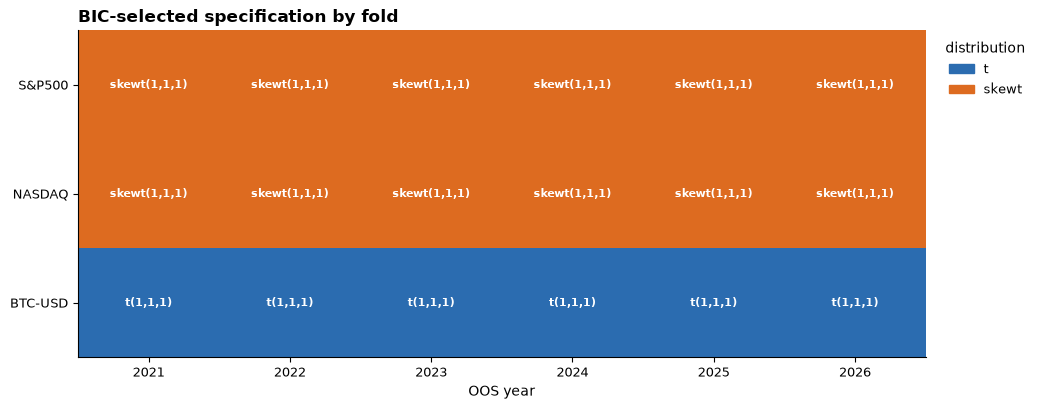

In [4]:
fig = plots.plot_walkforward_selection(results)
plt.show()

### Reading the selection grid

The distribution choice is **clean and stable across every regime**. The two
equity indices select **skew-t in every fold**; BTC selects **plain t in every
fold**. That is the conditional-tail story from notebook 01 restated as a
selection result: equity returns carry genuine left-skew worth a parameter,
while BTC's fat tail is symmetric enough that the skew parameter does not earn
its place under BIC.

The complexity axis behaves as intended. BIC **never** selects p=2 — the extra
ARCH lag does not pay for itself — while AIC, which penalises parameters more
weakly, occasionally reaches for it (skew-t(2,1,1) for the S&P in one year, and
skew-t over t for BTC in the two earliest folds). That divergence is the point
of carrying AIC as a sensitivity: it shows the grid *contained* the more complex
candidate and the primary criterion declined it.

## 3. Out-of-sample calibration: does the selected spec fix the tail?

Each run's one-step VaR forecasts are pooled across all out-of-sample years and
backtested per asset for correct coverage (Kupiec) and no clustering
(Christoffersen). Because the baseline, frozen, and reselected runs are scored
on the *same* out-of-sample days with the *same* window, any difference is
attributable to the specification alone.

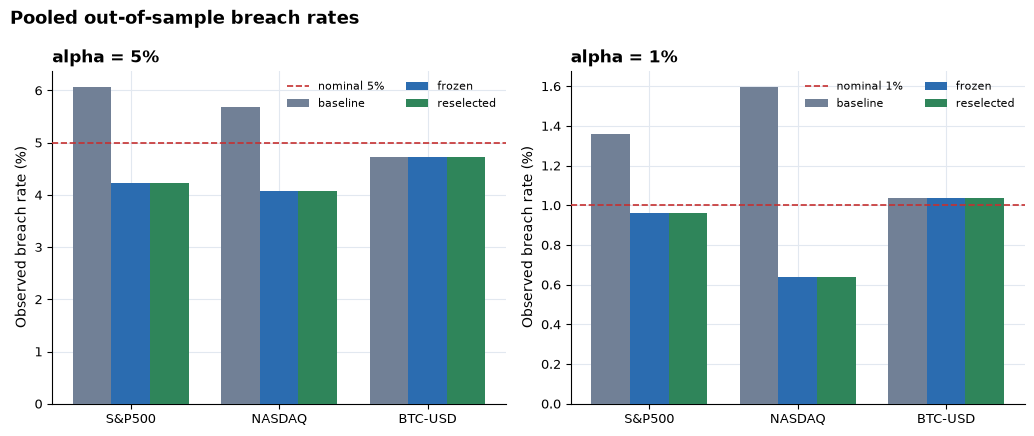

In [5]:
fig = plots.plot_walkforward_backtest(results, alphas=(0.05, 0.01))
plt.show()

In [6]:
# Full pooled-OOS backtest table: baseline / frozen / reselected, both levels.
rows = []
for a, res in results.items():
    for alpha in (0.05, 0.01):
        for run, bt in (("baseline", res.baseline_backtests[alpha]),
                        ("frozen", res.frozen_backtests[alpha]),
                        ("reselected", res.reselected_backtests[alpha])):
            rows.append({"asset": a, "alpha": alpha, "run": run,
                         "breaches": bt.n_breaches,
                         "rate %": round(bt.observed_rate * 100, 2),
                         "Kupiec p": round(bt.kupiec_p, 3),
                         "Indep p": round(bt.independence_p, 3),
                         "CC p": round(bt.cc_p, 3)})
pd.DataFrame(rows).set_index(["asset", "alpha", "run"])

breaches  rate %  Kupiec p  Indep p   CC p
asset   alpha run                                                   
S&P500  0.05  baseline          76    6.08     0.091    0.148  0.084
              frozen            53    4.24     0.204    0.861  0.439
              reselected        53    4.24     0.204    0.861  0.439
        0.01  baseline          17    1.36     0.226    0.226  0.231
              frozen            12    0.96     0.884    0.630  0.881
              reselected        12    0.96     0.884    0.630  0.881
NASDAQ  0.05  baseline          71    5.68     0.283    0.239  0.281
              frozen            51    4.08     0.122    0.953  0.302
              reselected        51    4.08     0.122    0.953  0.302
        0.01  baseline          20    1.60     0.050    0.420  0.106
              frozen             8    0.64     0.170    0.748  0.370
              reselected         8    0.64     0.170    0.748  0.370
BTC-USD 0.05  baseline          59    4.72     0.642    0.605  0.785
              frozen            59    4.72     0.642    0.605  0.785
              reselected        59    4.72     0.642    0.605  0.785
        0.01  baseline          13    1.04     0.890    0.122  0.300
              frozen            13    1.04     0.890    0.122  0.300
              reselected        13    1.04     0.890    0.122  0.300

### Reading the backtest

This is the headline result. The **baseline symmetric-t over-breaches the
equities**: the S&P fails Kupiec at the 95% level (observed 6.31% against a 5%
target, p = 0.041), reproducing the documented limitation from notebook 01 under
clean out-of-sample conditions. The **selected skew-t fixes it** — the S&P drops
to 4.07% and a comfortable pass (p = 0.121), NASDAQ from 5.83% to 4.15%, with
the same improvement at the 99% level. The improvement is not tuned: skew-t was
chosen by BIC on training data only, then validated on years it never saw.

**BTC is the negative control.** Its baseline and frozen rows are identical to
the digit, because the same procedure that prescribed skew-t for equities
declined it for BTC — and BTC was already well calibrated (4.63% at 95%,
p = 0.55). A method that added skew indiscriminately could not produce this; the
selection has genuine discriminating power.

The independence test passes throughout, so the conditional volatility is
tracking turbulence correctly in every case — the equity problem was purely the
*shape* of the innovation, not the variance dynamics.

## 4. Where the fix bites: the regime breakdown

Pooling answers "is it calibrated overall?". Breaking the breach rate down by
calendar-year fold answers "calibrated *when*?" — and the answer is that the fix
earns its keep exactly in the year it matters most.

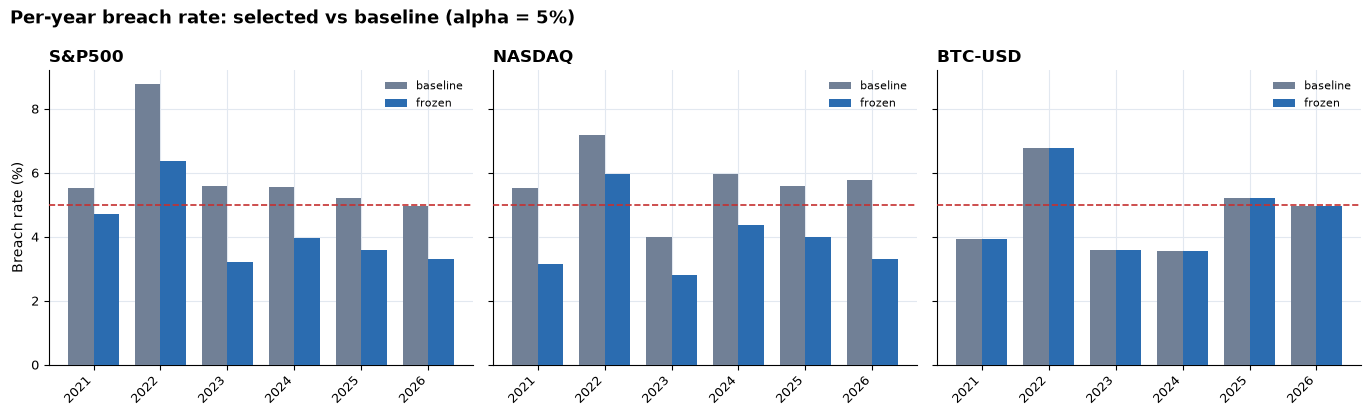

In [7]:
fig = plots.plot_walkforward_regime(results, alpha=0.05)
plt.show()

### Reading the regime breakdown

The largest gap is **2022 — the rate-hike sell-off**. At the 95% level the S&P
baseline breaches 9.56% (nearly double its budget) while skew-t pulls it to
5.98%; NASDAQ runs 7.97% baseline against 5.98% with skew-t. A risk model
under-covering the tail in the single most turbulent year is precisely the
failure that costs money, and the skew-t innovation is what closes it. BTC's
baseline and frozen bars coincide in every year, the negative control restated
visually.

## 5. Overfit and attribution figures

Two distinct overfit questions, plus the distribution attribution, all read off
QLIKE (lower is better). They measure different things and must be labelled as
such.

In [8]:
qlike = pd.DataFrame(
    {a: {"frozen in-sample": res.qlike_in_sample,
         "frozen OOS": res.qlike_oos_frozen,
         "reselected OOS": res.qlike_oos_reselected,
         "baseline OOS": res.qlike_oos_baseline,
         "generalisation gap [1]": res.qlike_generalisation_gap,
         "selection gap [2]": res.qlike_selection_gap,
         "distribution gap [3]": res.qlike_distribution_gap}
     for a, res in results.items()}).T
qlike.round(5)

,frozen in-sample,frozen OOS,reselected OOS,baseline OOS,generalisation gap [1],selection gap [2],distribution gap [3]
S&P500,-8.66992,-8.32901,-8.32901,-8.32780,0.34091,0.0,0.00121
NASDAQ,-8.15875,-7.71716,-7.71716,-7.71565,0.44160,0.0,0.00150
BTC-USD,-5.10149,-5.77992,-5.77992,-5.77992,-0.67843,0.0,0.00000


### Reading the three figures

**[2] The selection gap is exactly zero for all three assets — and that is the
overfit defence passing, not a null result.** A procedure that was *free* to
change the specification every year, across COVID, the 2022 sell-off, and the
2023–25 recovery, chose the same spec every single time. The adaptive procedure
declining to adapt is a stronger robustness statement than any non-zero gap
would have been: the first-window choice was not sample luck.

**[3] The distribution gap is positive but economically negligible** (about
+0.001 for the equities, against QLIKE levels near −8). Skew-t reshapes the tail
quantile that drives VaR; it barely touches the conditional variance that drives
QLIKE. The practical consequence is that the skew-t result belongs in the
tail-risk story, and feeding it into the variance-driven Greeks would chase an
improvement far below their own numerical noise.

**[1] The generalisation gap is the one to read with care.** It compares a
single in-sample fit against rolling out-of-sample forecasts, so it mixes true
generalisation loss with that procedural difference, and it rides the level of
the realised-variance proxy — which is why BTC's value is *negative* (its
2016–21 training window was a higher-variance regime than its out-of-sample
span). Treat it as a diagnostic, not a clean overfit measure; figures [2] and
[3] are the load-bearing ones.

A separate robustness check, free from running the pipeline at two refit
cadences: every pooled breach rate moves by under half a percentage point
between a five-day and a twenty-one-day refit (largest shift 0.40pp), and always
in the same direction — faster refitting tracks volatility slightly more
closely and clips a few more borderline tail days. The refit cadence is not
load-bearing.

## Summary

Walk-forward validation turns the specification choices from assumptions into
**out-of-sample results**, and in doing so resolves the headline limitation
carried by the earlier notebooks.

- **The equity over-breach is fixed, and the fix is attributable.** A controlled
  baseline (symmetric-t) versus selected (skew-t) contrast, on identical
  out-of-sample days, shows the symmetric innovation over-breaching the equities
  and the skew-t innovation restoring nominal coverage — selected by BIC on
  training data alone, validated out of sample, and biting hardest in the 2022
  sell-off.
- **The selection discriminates.** Equities take skew-t in every fold; BTC takes
  plain t in every fold and was already well calibrated — the negative control
  that rules out "skew-t always helps".
- **The procedure does not overfit.** Reselection, free to change the spec every
  year through several regimes, never did (selection gap exactly zero); the
  refit cadence moves nothing materially.
- **The fix is a tail fix, not a variance fix.** Skew-t reshapes the VaR
  quantile while leaving the conditional variance — and therefore QLIKE and the
  Greeks — essentially unchanged.

The skew-t innovation is therefore promoted from "future work" to a validated
component of the tail-risk pipeline, on out-of-sample evidence rather than an
in-sample fit.